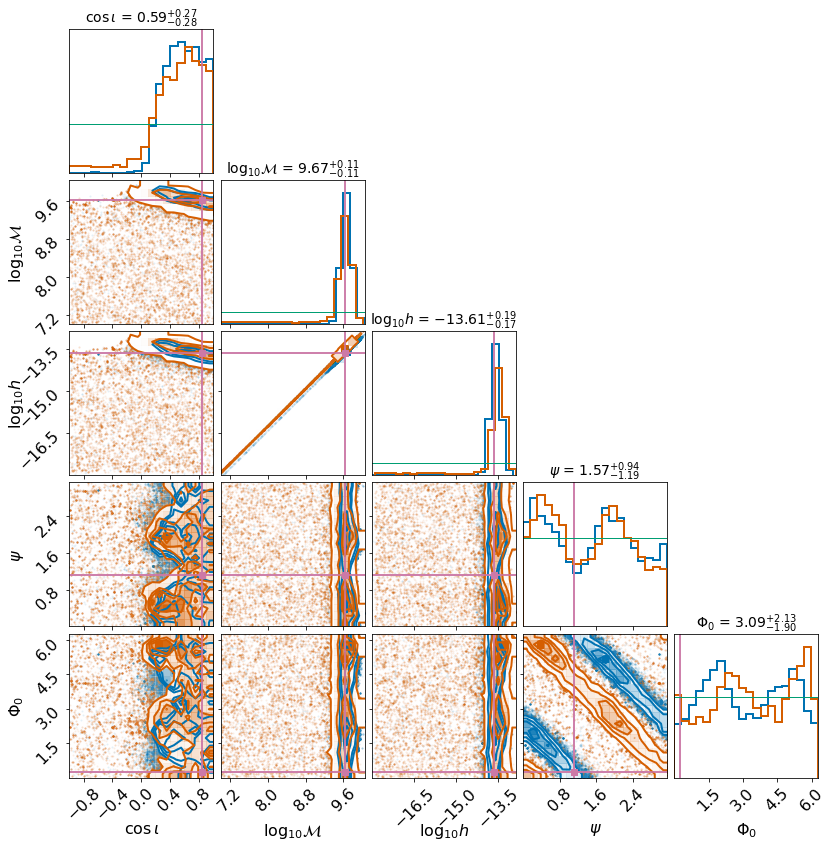

In [25]:
#!/usr/bin/env python
# coding: utf-8

import numpy as np
import h5py
import matplotlib.pyplot as plt
import corner

# ============================================================
# 1. Truth values (QuickCW naming)
# ============================================================
truth = {
    "0_cos_inc":   0.8412486994612669,
    "0_log10_mc":  np.log10(4.3e9),
    "0_log10_h":   -13.668773493298787,
    "0_psi":       1.1187560505283651,
    "0_phase0":    0.24434609527920614,
}

qc_keys = ["0_cos_inc", "0_log10_mc", "0_log10_h", "0_psi", "0_phase0"]
labels  = [
    r"$\cos\iota$",
    r"$\log_{10}\mathcal{M}$",
    r"$\log_{10} h$",
    r"$\psi$",
    r"$\Phi_0$"
]

# ============================================================
# 2. Priors (green lines)
# ============================================================
def add_priors(ax, i):
    if i == 0:  # cos(iota)
        X = np.linspace(-1,1)
        ax.plot(X, X*0 + 1/2, color="#009E73", lw=1)

    elif i in (1,2):  # log10 M, log10 h
        xl, xr = ax.get_xlim()
        X = np.linspace(xl, xr)
        ax.plot(X, X*0 + 1/(xr-xl), color="#009E73", lw=1)

    elif i == 3:  # psi
        X = np.linspace(0, np.pi)
        ax.plot(X, X*0 + 1/np.pi, color="#009E73", lw=1)

    elif i == 4:  # phase0
        X = np.linspace(0, 2*np.pi)
        ax.plot(X, X*0 + 1/(2*np.pi), color="#009E73", lw=1)


# ============================================================
# 3. Load QuickCW
# ============================================================
quickcw_file = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/"
    "G2D2_narrow_detect_dLmasked_75.400Mpc.h5"
)

with h5py.File(quickcw_file, "r") as f:
    qc_samples = f["samples_masked"][...]
    qc_params  = [x.decode("utf-8") for x in f["par_names"][...]]

qc_plot = np.column_stack([qc_samples[:, qc_params.index(k)] for k in qc_keys])


# ============================================================
# 4. Load Enterprise
# ============================================================
enterprise_file = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/"
    "ent_files/D2_det_core_single.h5"
)

with h5py.File(enterprise_file, "r") as f:
    e_samples = f["chain"][...]
    e_params  = [p.decode("utf-8") for p in f["params"][...]]
    burn      = f["metadata/burn"][()]

e_samples = e_samples[burn:, :]

ent_map = {
    "0_cos_inc":  "cos_inc",
    "0_log10_mc": "log10_mc",
    "0_log10_h":  "log10_h0",     # no transformation (as requested)
    "0_psi":      "psi",
    "0_phase0":   "phase0",
}

ent_plot = np.column_stack([e_samples[:, e_params.index(ent_map[k])] for k in qc_keys])


# ============================================================
# 5. Fonts (your template)
# ============================================================
plt.rcParams["font.size"] = 16
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16

# colors
c_qc  = "#0072B2"
c_ent = "#D55E00"
c_truth = "#CC79A7"
c_prior = "#009E73"

# ============================================================
# 6. Main corner plot (QuickCW)
# ============================================================
fig = corner.corner(
    qc_plot,
    labels=labels,
    truths=[truth[k] for k in qc_keys],
    truth_color=c_truth,
    color=c_qc,
    show_titles=True,
    hist_kwargs=dict(density=True, color=c_qc, linewidth=2.0),
    contour_kwargs=dict(colors=[c_qc], linewidths=2.0),
    label_kwargs={"fontsize": 16},
    fill_contours=False,     # you can set True to shade
)

# ============================================================
# 7. Overlay Enterprise (thicker lines)
# ============================================================
corner.corner(
    ent_plot,
    fig=fig,
    labels=labels,
    truths=[truth[k] for k in qc_keys],
    truth_color=c_truth,
    color=c_ent,
    show_titles=False,
    hist_kwargs=dict(density=True, color=c_ent, linewidth=2.0),
    contour_kwargs=dict(colors=[c_ent], linewidths=2.0),
    fill_contours=False,
)

# ============================================================
# 8. Draw priors (1D only)
# ============================================================
axes = np.array(fig.axes).reshape(len(labels), len(labels))
for i in range(len(labels)):
    add_priors(axes[i, i], i)

# ============================================================
# 9. Format
# ============================================================
for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=16)

plt.show()


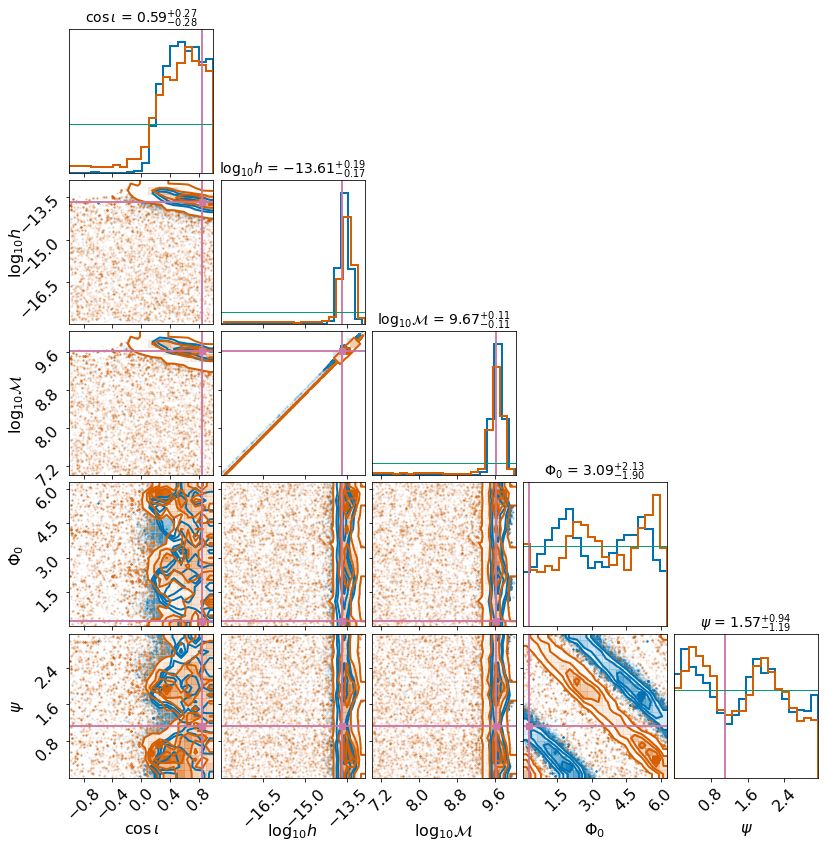

In [30]:
#!/usr/bin/env python
# coding: utf-8

import numpy as np
import h5py
import matplotlib.pyplot as plt
import corner

# ============================================================
# 1. Truth values (QuickCW naming)
# ============================================================
truth = {
    "0_cos_inc":   0.8412486994612669,
    "0_log10_h":   -13.668773493298787,    # strain second
    "0_log10_mc":  np.log10(4.3e9),        # mass third
    "0_phase0":    0.24434609527920614,    # phase fourth
    "0_psi":       1.1187560505283651,     # psi last
}

# NEW ORDER
qc_keys = [
    "0_cos_inc",
    "0_log10_h",
    "0_log10_mc",
    "0_phase0",
    "0_psi",
]

labels = [
    r"$\cos\iota$",
    r"$\log_{10} h$",
    r"$\log_{10}\mathcal{M}$",
    r"$\Phi_0$",
    r"$\psi$",
]

# ============================================================
# 2. Priors (green lines)
# (Updated indices to match new order)
# ============================================================
def add_priors(ax, i):

    if i == 0:  # cos iota
        X = np.linspace(-1, 1)
        ax.plot(X, X*0 + 1/2, color="#009E73", lw=1)

    elif i == 1:  # log10 h
        xl, xr = ax.get_xlim()
        X = np.linspace(xl, xr)
        ax.plot(X, X*0 + 1/(xr-xl), color="#009E73", lw=1)

    elif i == 2:  # log10 Mc
        xl, xr = ax.get_xlim()
        X = np.linspace(xl, xr)
        ax.plot(X, X*0 + 1/(xr-xl), color="#009E73", lw=1)

    elif i == 3:  # phase0 ∈ [0, 2π]
        X = np.linspace(0, 2*np.pi)
        ax.plot(X, X*0 + 1/(2*np.pi), color="#009E73", lw=1)

    elif i == 4:  # psi ∈ [0, π]
        X = np.linspace(0, np.pi)
        ax.plot(X, X*0 + 1/np.pi, color="#009E73", lw=1)


# ============================================================
# 3. Load QuickCW
# ============================================================
quickcw_file = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/"
    "G2D2_narrow_detect_dLmasked_75.400Mpc.h5"
)

with h5py.File(quickcw_file, "r") as f:
    qc_samples = f["samples_masked"][...]
    qc_params  = [x.decode("utf-8") for x in f["par_names"][...]]

qc_plot = np.column_stack([qc_samples[:, qc_params.index(k)] for k in qc_keys])


# ============================================================
# 4. Load Enterprise
# ============================================================
enterprise_file = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/"
    "ent_files/D2_det_core_single.h5"
)

with h5py.File(enterprise_file, "r") as f:
    e_samples = f["chain"][...]
    e_params  = [p.decode("utf-8") for p in f["params"][...]]
    burn      = f["metadata/burn"][()]

e_samples = e_samples[burn:, :]

# NEW ORDER MAPPING
ent_map = {
    "0_cos_inc":  "cos_inc",
    "0_log10_h":  "log10_h0",
    "0_log10_mc": "log10_mc",
    "0_phase0":   "phase0",
    "0_psi":      "psi",
}

ent_plot = np.column_stack([e_samples[:, e_params.index(ent_map[k])] 
                            for k in qc_keys])


# ============================================================
# 5. Fonts
# ============================================================
plt.rcParams["font.size"] = 16
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16

# colors
c_qc    = "#0072B2"
c_ent   = "#D55E00"
c_truth = "#CC79A7"
c_prior = "#009E73"


# ============================================================
# 6. Main QuickCW corner plot
# ============================================================
fig = corner.corner(
    qc_plot,
    labels=labels,
    truths=[truth[k] for k in qc_keys],
    truth_color=c_truth,
    color=c_qc,
    show_titles=True,
    hist_kwargs=dict(density=True, color=c_qc, linewidth=2.0),
    contour_kwargs=dict(colors=[c_qc], linewidths=2.0),
    label_kwargs={"fontsize": 16},
    fill_contours=False,
)

# ============================================================
# 7. Overlay Enterprise
# ============================================================
corner.corner(
    ent_plot,
    fig=fig,
    labels=labels,
    truths=[truth[k] for k in qc_keys],
    truth_color=c_truth,
    color=c_ent,
    show_titles=False,
    hist_kwargs=dict(density=True, color=c_ent, linewidth=2.0),
    contour_kwargs=dict(colors=[c_ent], linewidths=2.0),
    fill_contours=False,
)

# ============================================================
# 8. Draw priors on diagonals
# ============================================================
axes = np.array(fig.axes).reshape(len(labels), len(labels))
for i in range(len(labels)):
    add_priors(axes[i, i], i)

# ============================================================
# 9. Format
# ============================================================
for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=16)

plt.show()


In [29]:
from enterprise_extensions import model_utils
# amplitude column in qc_plot = column index 3 if you included fgw
# but in your 5-parameter version, log10_h was index=2
qc_amp = qc_plot[:, qc_keys.index("0_log10_h")]

qc_BF, qc_BF_err = model_utils.bayes_fac(
    samples=qc_amp,
    logAmax=-11
)

print(f"QuickCW SD Bayes Factor: {qc_BF:.4f} ± {qc_BF_err:.4f}")

ent_amp = ent_plot[:, qc_keys.index("0_log10_h")]

ent_BF, ent_BF_err = model_utils.bayes_fac(
    samples=ent_amp,
    logAmax=-11
)

print(f"Enterprise SD Bayes Factor: {ent_BF:.4f} ± {ent_BF_err:.4f}")


QuickCW SD Bayes Factor: nan ± nan
Enterprise SD Bayes Factor: nan ± nan


/usr/local/anaconda/lib/python3.9/site-packages/enterprise_extensions/model_utils.py:194: RuntimeWarning: divide by zero encountered in double_scalars
  bf.append(prior/post)


## Corner Plots

## SD BF

In [18]:
#Non d_L correlated SD BF
from enterprise_extensions import model_utils
BF,BF_err = model_utils.bayes_fac(samples = samples_cold[0][::10,4], logAmax=-11)
print(f"log10A BF = {BF:.4f} ± {BF_err:.4f}")

log10A BF = 209.4529 ± 3.5302


In [19]:
print(BF_arr[0:10])

[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]


In [20]:
print(BF_err_arr[0:10])

[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]
